# Caso: Clasificación de textos como Positivo o Negativo o _Sentiment Analysis_

Vamos a ver un ejemplo sencillo de clasificación de texto, haciendo un sentiment análisis de frases o positivas o negativas.

In [1]:
# Importamos

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('https://github.com/palasatenea66/DATASETS/raw/main/sentimientos.xls', header=None)
df.columns = ['Texto', 'Sentimiento']
df.sample(10)

,Texto,Sentimiento
426,Sobre la tragedia del metro de Valencia... htt...,neg
494,lo tendré en cuenta. Pero no parece cercano......,neg
1056,"Bueno, resfriados estamos muchos.. Pero A Cor...",pos
907,"Gracias, Carmen: los socialistas andaluces est...",pos
113,La izquierda debe superar la resignación y la ...,neg
1420,"El jueves asisto al acto de reapertura, tras s...",pos
1480,"“ja, ja, ja!!! Me sobrevaloras @Nica_Neri: @Bu...",pos
887,Tan sólo seremos libres cuando no haya más que...,pos
1450,"Me reafirmo, día histórico, el supremo defiend...",pos
670,Un político faltón y desabrido ha emplazado ho...,neg


In [4]:
df.shape

(1607, 2)

In [3]:
df['Sentimiento'].value_counts()

,count
Sentimiento,
neg,808
pos,799


In [5]:
# separamos train y test
train, test = train_test_split(df, test_size=0.25)

In [ ]:
# 🔹 Separamos el dataset en variables de entrada (X) y salida (y)
# Usamos iloc para seleccionar por posición de columna:
# - Columna 0 → texto (características)
# - Columna 1 → etiqueta o clase (por ejemplo, "spam" o "no spam")
train_y = train.iloc[:, 1]
train_X = train.iloc[:, 0]
test_y = test.iloc[:, 1]
test_X = test.iloc[:, 0]

# 🔹 Creamos el vectorizador TF-IDF
# TF-IDF (Term Frequency - Inverse Document Frequency) transforma los textos en una matriz numérica
# donde cada palabra recibe un peso según su frecuencia en el documento y en el corpus
# min_df=3 → ignora palabras que aparezcan en menos de 3 documentos
vec = TfidfVectorizer(min_df=3)

# 🔹 Creamos el modelo Naive Bayes Multinomial (adecuado para texto y conteo de palabras)
model = MultinomialNB()

# 🔹 Creamos un pipeline que encadena el vectorizador y el modelo
# Así, cuando se entrena o predice, primero se transforma el texto a TF-IDF
# y luego se entrena o evalúa el clasificador
clf = make_pipeline(vec, model)

# 🔹 Entrenamos el pipeline con los textos y sus etiquetas correspondientes
# Internamente:
#   1. Se ajusta el vectorizador TF-IDF con los textos de train_X
#   2. Se entrena el modelo Naive Bayes con las representaciones numéricas
clf = clf.fit(train_X, train_y)


In [7]:
test_X

,Texto
1240,"Es mas me voy a retirar de twitter, gracias po..."
1329,¡Lo mejor de mi timeline está disponible! http...
861,Zapatero dice que Rajoy ha comprendido perfect...
508,Por problemas técnicos no se podrá tener acces...
1356,Grandes predicciones de la Historia #38congres...
...,...
327,Pues el logo de #Madrid2020 no me gusta... Tan...
561,Los partos prematuros se han triplicado por cu...
513,"No podemos dejarnos seducir por los que, con e..."
111,En España se mueven unos 56.000 mill€ en bille...


In [8]:
predictions = clf.predict(test_X)

In [9]:
sum(predictions == test_y) / len(test_y)

0.7661691542288557

In [10]:
accuracy_score(test_y, predictions)

0.7661691542288557

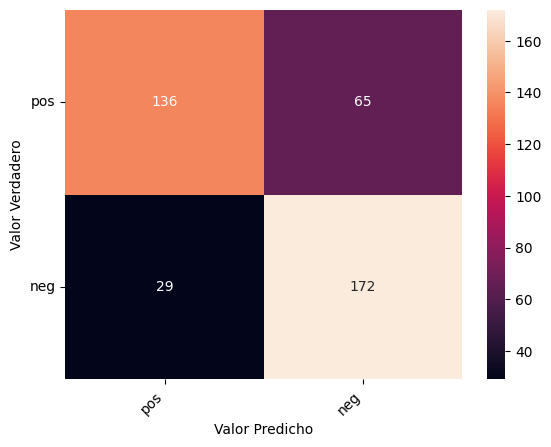

In [11]:
df_cm = confusion_matrix(test_y,predictions,labels=test_y.unique())
heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
heatmap.yaxis.set_ticklabels(test_y.unique(), rotation=0, ha='right')
heatmap.xaxis.set_ticklabels(test_y.unique(), rotation=45, ha='right')
plt.ylabel('Valor Verdadero')
plt.xlabel('Valor Predicho');

In [12]:
to_predict = "Hace un cálido día soleado en Buenos Aires"
clf.predict([to_predict])[0]

np.str_('pos')

In [13]:
to_predict = "Cayeron las acciones tecnológicas en las bolsas de todo el mundo"
clf.predict([to_predict])[0]

np.str_('pos')